In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import sklearn.cluster as cluster
import numpy as np
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
path = "birch3.txt"
df = pd.read_csv(path, sep=" ", header=None, names=["X", "Y"])

## Granularity matters to judge if cluster good or not

<Axes: xlabel='X', ylabel='Y'>

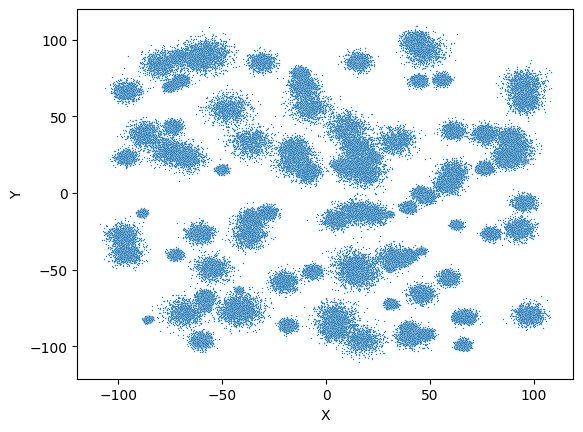

In [43]:
# Highest granularity
sns.scatterplot(df, x="X", y="Y", s=1)

<Axes: xlabel='X', ylabel='Y'>

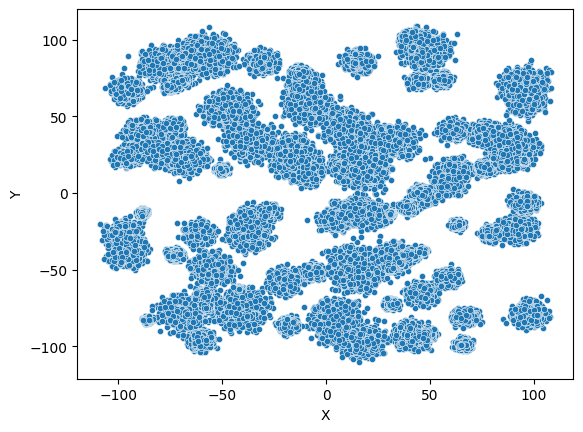

In [44]:
sns.scatterplot(df, x="X", y="Y", s=20)

K-Means
DBScan
Optics
Birch

## Which cluster algorithms to evaluate?


According to https://scikit-learn.org/stable/modules/clustering.html, there
are several clustering algorithms. Below the comment if they work or not:

    * K-Means & variants: We don't have even cluster size, and we have many
    clusters.
    * Affinity propagation: For small datasets, as very complex O(N^2 T).
    N=100K in our case. We get memory error.
    * Mean-shift: Same as for affinity propagation. Not scalable.
    * Spectral Clustering: Designed for small number of clusters. We have
    more like 20-30 clusters here, so not good.
    * Agglomerative Clustering (e.g. Ward): Too computationally heavy.
    Computes distance between all clusters and starts off at every data point
     being one cluster (we have 100k data points). It could work, if we added
      connectivity constraints (maybe s.th. with k-nearest neighbors?). But
      let's continue with the other methods first.
    * DBSCAN / HDBSCAN:
    * OPTICS:
    * Gaussian Mixtures:
    * BIRCH:

## K-Means

In [5]:
# K-Means clustering
n_clust = 30

X = df[['X', 'Y']].values
kmeans = cluster.KMeans(n_clusters=n_clust, random_state=32)
kmeans.fit(X)

# Cluster labels
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

df["Cluster"] = labels
df["Cluster"] = df["Cluster"].astype(str)

In [6]:
#metrics.silhouette_score(df, labels, metric="euclidean")

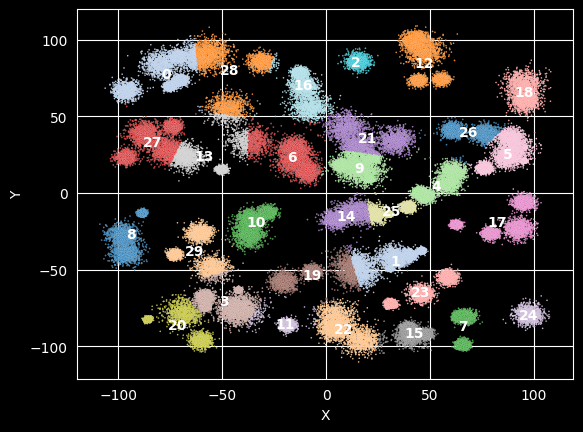

In [7]:
sns.scatterplot(data=df, x='X', y='Y', hue='Cluster', s=1, legend=False,
                palette='tab20')

# Annotate cluster numbers at centroids
for i, (cx, cy) in enumerate(centroids):
    plt.text(
        cx, cy,
        str(i),
        fontsize=10,
        weight='bold',
        ha='center',
        va='center'
    )

Conclusion: Not optimal clustering of the points. Why? Clusters have
different sizes. Many clusters.
K-means good if cluster size even and not too many clusters.

## Playground

In [8]:
# # Sample data
# sample_df = df.sample(100, random_state=42)

# X_sample = df[['X','Y']].values

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X_sample)

# ward = cluster.AgglomerativeClustering(
#     n_clusters=30,
#     linkage="ward"
# )

# labels = ward.fit_predict(X_scaled)

# sample_df["Ward_cluster"] = labels

In [9]:
# plt.figure(figsize=(8,8))

# sns.scatterplot(
#     x=df['X'],
#     y=df['Y'],
#     hue=df['AP_Cluster'],
#     palette='tab20',
#     s=5,
#     legend=False
# )

# # Get actual centroid coordinates (unscaled)
# centroids_scaled = X_scaled[cluster_centers_indices]
# centroids = scaler.inverse_transform(centroids_scaled)

# # Label clusters at exemplars
# for i, (cx, cy) in enumerate(centroids):
#     plt.text(
#         cx, cy,
#         str(i),
#         fontsize=10,
#         weight='bold',
#         ha='center',
#         va='center',
#         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
#     )

# plt.title(f"Affinity Propagation Clusters ({n_clusters} found)")
# plt.show()

In [10]:
#pip install --upgrade scipy  # fixes numpy 2.x compatibility

## Additional Imports for Remaining Algorithms

In [11]:
from sklearn.cluster import DBSCAN, HDBSCAN, OPTICS, Birch
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics.cluster import pair_confusion_matrix
import warnings
warnings.filterwarnings('ignore')

X   = df[['X', 'Y']].values      # full 100K × 2 array
rng = np.random.default_rng(42)   # reproducible sampling

## Multiple K-Means — Finding the Best K

BIRCH-3 has clusters of **varying density and size**, so K-Means is not ideal.
But by sweeping over several values of K we can quantify the degradation and
pick the best possible K before moving to better-suited algorithms.

| Metric | Goal | Formula |
|--------|------|---------|
| **Inertia (Elbow)** | ↓ | Sum of squared distances to centroid |
| **Silhouette Score** | ↑ ∈ (−1, 1) | Cohesion vs. separation |
| **Davies-Bouldin** | ↓ ≥ 0 | Mean cluster similarity (lower = crisper) |

Silhouette is O(n²) — we compute it on a 10 K random subsample.

In [39]:
k_values = [10, 20, 30, 50, 100]
km_results = {}

sil_idx = rng.choice(len(X), size=10_000, replace=False)
X_sil   = X[sil_idx]

for k in k_values:
    print(f"  KMeans k={k} ...", end=" ", flush=True)
    km  = cluster.KMeans(n_clusters=k, random_state=42, n_init=5)
    lbl = km.fit_predict(X)
    sil = silhouette_score(X_sil, lbl[sil_idx])
    db  = davies_bouldin_score(X, lbl)
    km_results[k] = dict(inertia=km.inertia_,
                         silhouette=sil,
                         davies_bouldin=db,
                         labels=lbl,
                         centroids=km.cluster_centers_)
    print(f"sil={sil:.3f}  DB={db:.3f}")
print("Done.")

  KMeans k=10 ... sil=0.422  DB=0.753
  KMeans k=20 ... sil=0.513  DB=0.648
  KMeans k=30 ... sil=0.508  DB=0.710
  KMeans k=50 ... sil=0.565  DB=0.585
  KMeans k=100 ... sil=0.560  DB=0.713
Done.


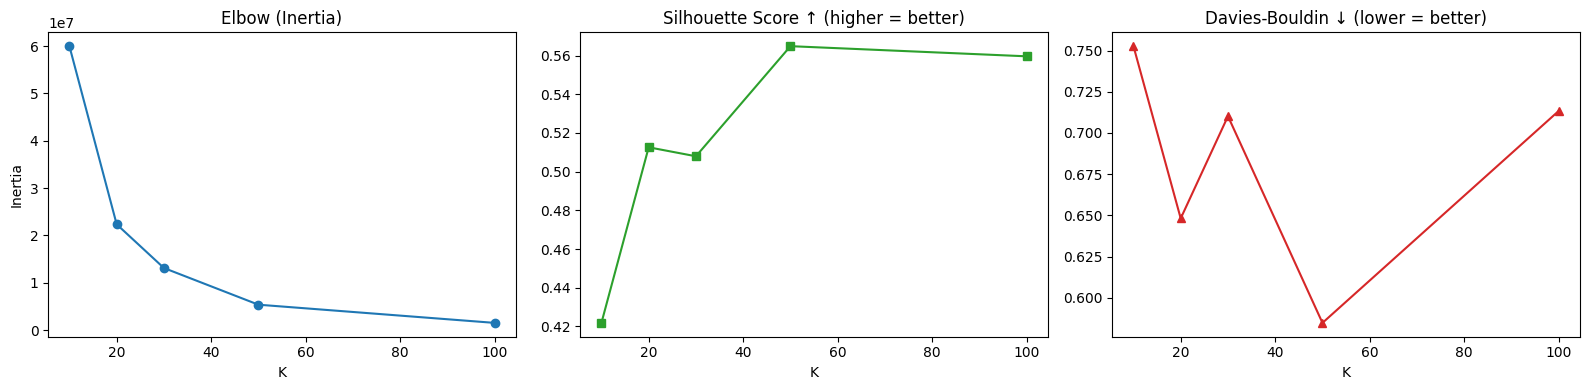

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ks = list(km_results)

axes[0].plot(ks, [km_results[k]['inertia']        for k in ks], 'o-')
axes[0].set(title='Elbow (Inertia)', xlabel='K', ylabel='Inertia')

axes[1].plot(ks, [km_results[k]['silhouette']     for k in ks], 's-', color='tab:green')
axes[1].set(title='Silhouette Score ↑ (higher = better)', xlabel='K')

axes[2].plot(ks, [km_results[k]['davies_bouldin'] for k in ks], '^-', color='tab:red')
axes[2].set(title='Davies-Bouldin ↓ (lower = better)', xlabel='K')

plt.tight_layout()
plt.show()

Best K by silhouette: 50


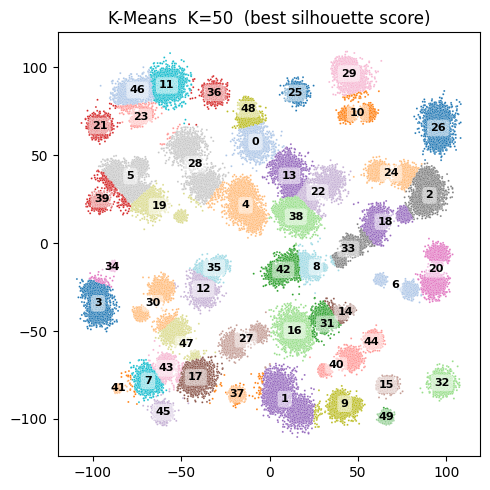

In [51]:
best_k = max(km_results, key=lambda k: km_results[k]['silhouette'])
print(f"Best K by silhouette: {best_k}")

labels_kmeans  = km_results[best_k]['labels']
centroids_best = km_results[best_k]['centroids']

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_kmeans.astype(str),
                s=2, legend=False, palette='tab20', ax=ax)
for i, (cx, cy) in enumerate(centroids_best):
    ax.text(cx, cy, str(i), fontsize=8, ha='center', va='center',
            fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none',
                      boxstyle='round'))
ax.set_title(f'K-Means  K={best_k}  (best silhouette score)')
plt.tight_layout()
plt.show()

## DBSCAN

DBSCAN groups points reachable within a radius **eps** from **min_samples** core points.
Points that belong to no cluster are marked **noise (−1)**.
Advantages over K-Means: handles arbitrary shapes and varying density;
disadvantage: sensitive to **eps** — we choose it with a k-NN distance plot.

**Rule of thumb:** plot the distance to the k-th nearest neighbour sorted ascending.
The elbow of this curve gives a good `eps`.
''The idea behind this heuristic is that points located inside of clusters
will have a small k-nearest neighbor distance, because they are close to
other points in the same cluster, while noise points are more isolated and
will have a rather large kNN distance.'' from paper: dbscan: Fast
Density-Based Clustering with R, https://www.jstatsoft.org/article/view/v091i01

Good results with the pair (nn_k, eps) for the following configurations:
(20, 2.2), (15, 2.7), (10, 2), (15, 1.2)

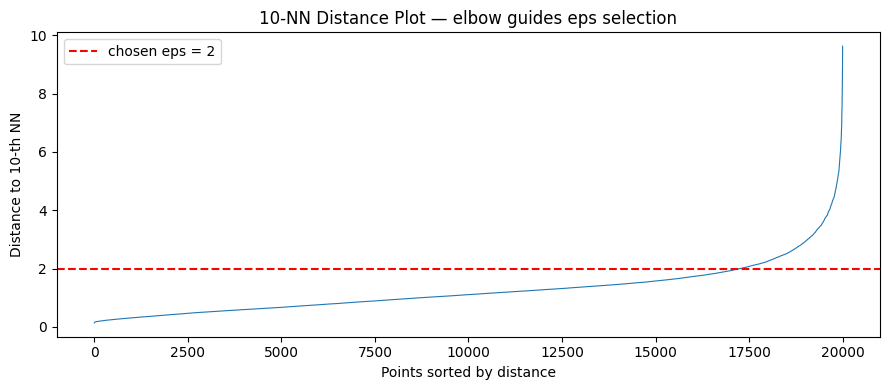

DBSCAN -> 38 clusters | 808 noise pts (0.8%)


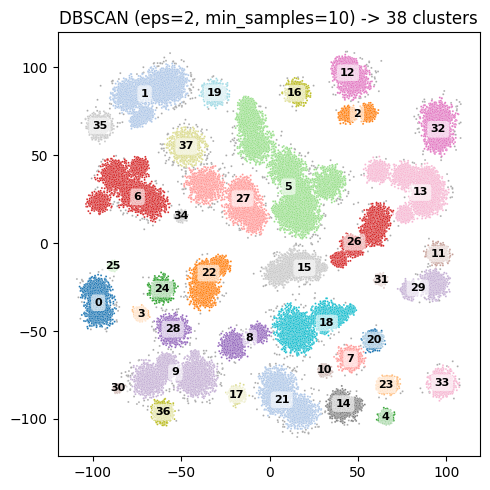

In [52]:
# k-NN distance plot to guide eps selection, i thought we could get better metrics?
nn_k = 10 #20 #15 #10 #15
eps = 2   #2.2#2.7#2 #1.2
knn_idx = rng.choice(len(X), size=20000, replace=False)
nn = NearestNeighbors(n_neighbors=nn_k, n_jobs=-1)
nn.fit(X[knn_idx])
dists, _ = nn.kneighbors(X[knn_idx])
kth = np.sort(dists[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(kth, lw=0.8)
plt.axhline(eps, color='r', ls='--', label=f'chosen eps = {eps}')
plt.title(f'{nn_k}-NN Distance Plot — elbow guides eps selection')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {nn_k}-th NN')
plt.legend()
plt.tight_layout()
plt.show()

# Fit DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=nn_k, n_jobs=-1)
labels_dbscan = dbscan.fit_predict(X)

n_cl_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = int((labels_dbscan == -1).sum())
print(f"DBSCAN -> {n_cl_db} clusters | {n_noise_db} noise pts "
      f"({n_noise_db / len(X) * 100:.1f}%)")

# Visualise
palette_db = ['#aaaaaa'] + list(sns.color_palette('tab20', max(n_cl_db, 1)))
hue_order  = [str(x) for x in sorted(set(labels_dbscan))]

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_dbscan.astype(str),
                hue_order=hue_order, palette=palette_db,
                s=2, legend=False, ax=ax)

# Centroids (exclude noise = -1)
unique_labels = sorted(l for l in set(labels_dbscan) if l != -1)
centroids = []
for label in unique_labels:
    cluster_points = X[labels_dbscan == label]
    centroid = np.median(cluster_points, axis=0)  # median for better placement
    centroids.append(centroid)
centroids = np.array(centroids)

for label, (cx, cy) in zip(unique_labels, centroids):
    ax.text(cx, cy,
            str(label),
            fontsize=8,
            ha='center',
            va='center',
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white',
                      alpha=0.6,
                      edgecolor='none',
                      boxstyle='round'))

ax.set_title(f'DBSCAN (eps={eps}, min_samples={nn_k}) -> {n_cl_db} clusters')
plt.tight_layout()
plt.show()

## HDBSCAN

**Hierarchical DBSCAN** builds a full density hierarchy and extracts the
most stable flat clustering automatically — no `eps` needed.
Only `min_cluster_size` must be set (minimum points to form a cluster).
It handles **varying-density clusters** better than plain DBSCAN,
which makes it particularly well-suited for BIRCH-3.

HDBSCAN -> 72 clusters | 11331 noise pts (11.3%)


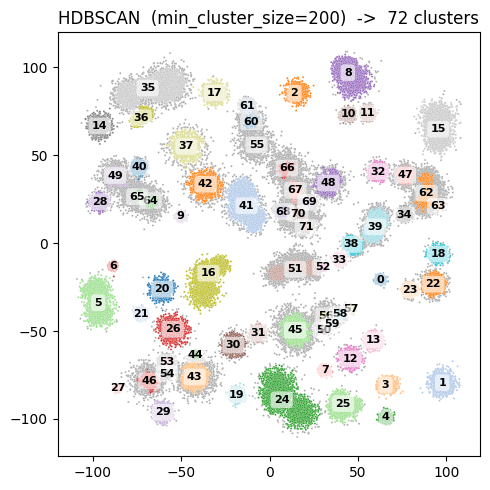

In [55]:
hdb = HDBSCAN(min_cluster_size=200, min_samples=10, n_jobs=-1)
labels_hdbscan = hdb.fit_predict(X)

n_cl_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise_hdb = int((labels_hdbscan == -1).sum())
print(f"HDBSCAN -> {n_cl_hdb} clusters | {n_noise_hdb} noise pts "
      f"({n_noise_hdb / len(X) * 100:.1f}%)")

palette_hdb   = ['#aaaaaa'] + list(sns.color_palette('tab20', max(n_cl_hdb, 1)))
hue_order_hdb = [str(x) for x in sorted(set(labels_hdbscan))]

fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_hdbscan.astype(str),
                hue_order=hue_order_hdb, palette=palette_hdb,
                s=2, legend=False, ax=ax)

# Centroids (exclude noise = -1)
unique_labels = sorted(l for l in set(labels_hdbscan) if l != -1)
centroids = []
for label in unique_labels:
    cluster_points = X[labels_hdbscan == label]
    centroid = np.median(cluster_points, axis=0)  # median for better placement
    centroids.append(centroid)
centroids = np.array(centroids)

for label, (cx, cy) in zip(unique_labels, centroids):
    ax.text(cx, cy,
            str(label),
            fontsize=8,
            ha='center',
            va='center',
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white',
                      alpha=0.6,
                      edgecolor='none',
                      boxstyle='round'))

ax.set_title(f'HDBSCAN  (min_cluster_size=200)  ->  {n_cl_hdb} clusters')
plt.tight_layout()
plt.show()

## OPTICS

OPTICS (Ordering Points To Identify the Clustering Structure) produces a
**reachability plot** where valleys correspond to clusters at different densities.
It is a superset of DBSCAN and requires no fixed `eps`.

Complexity is $O(n \log n)$ — manageable, but we subsample to **20 K points**
to keep runtime reasonable.  The key outputs are:
- `reachability_` — distance used to enter each point
- `ordering_` — the traversal order that makes valleys visible

OPTICS (subsample 20000) -> 17 clusters | 9127 noise pts


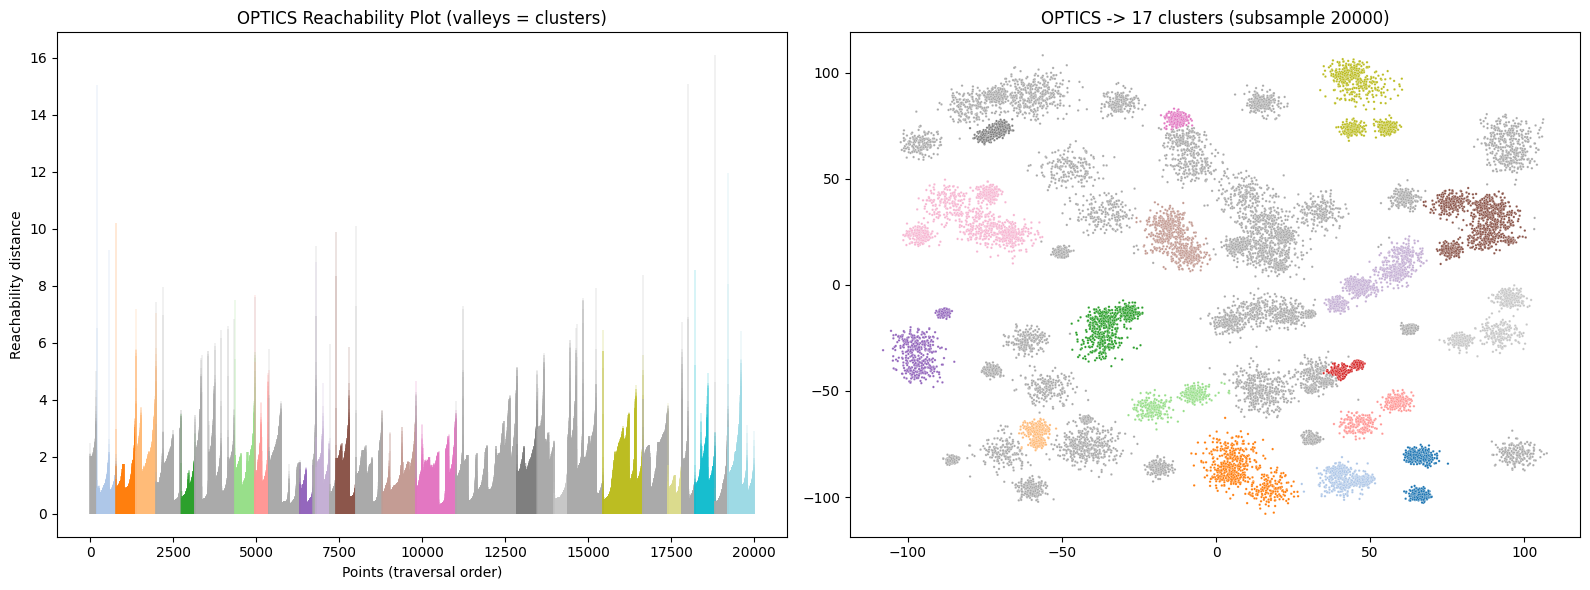

In [56]:
optics_n = 20_000
optics_idx = rng.choice(len(X), size=optics_n, replace=False)
X_op = X[optics_idx]

optics = OPTICS(min_samples=30, xi=0.05, min_cluster_size=0.02, n_jobs=-1)
labels_optics_sub = optics.fit_predict(X_op)

n_cl_op = len(set(labels_optics_sub)) - (1 if -1 in labels_optics_sub else 0)
n_noise_op = int((labels_optics_sub == -1).sum())
print(f"OPTICS (subsample {optics_n}) -> {n_cl_op} clusters | {n_noise_op} noise pts")

# Reachability plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

space = np.arange(len(X_op))
reachability = optics.reachability_[optics.ordering_]
lbl_ordered = labels_optics_sub[optics.ordering_]
unique_lbls = sorted(set(labels_optics_sub))
cmap = plt.cm.tab20(np.linspace(0, 1, max(len(unique_lbls), 2)))
cmap_dict = {l: ('#aaaaaa' if l == -1 else cmap[i % 20])
                for i, l in enumerate(unique_lbls)}

for xi, yi, lbl in zip(space, reachability, lbl_ordered):
    axes[0].vlines(xi, 0, yi, color=cmap_dict[lbl], lw=0.3, alpha=0.8)
axes[0].set(title='OPTICS Reachability Plot (valleys = clusters)',
            xlabel='Points (traversal order)', ylabel='Reachability distance')

# Scatter
palette_op = ['#aaaaaa'] + list(sns.color_palette('tab20', max(n_cl_op, 1)))
hue_order_op = [str(x) for x in sorted(set(labels_optics_sub))]
sns.scatterplot(x=X_op[:, 0], y=X_op[:, 1], hue=labels_optics_sub.astype(str),
                hue_order=hue_order_op, palette=palette_op,
                s=3, legend=False, ax=axes[1])
axes[1].set_title(f'OPTICS -> {n_cl_op} clusters (subsample {optics_n})')

plt.tight_layout()
plt.show()

## Gaussian Mixtures

A **Gaussian Mixture Model (GMM)** treats each cluster as a Gaussian distribution.
Unlike K-Means (hard assignment), GMM gives each point a *soft probability*
of belonging to each component.

We use **diagonal covariance** (efficient for 2D) and select `n_components`
via the **Bayesian Information Criterion (BIC)** — lower BIC = better trade-off
between fit quality and model complexity.

GMM n=20 ... BIC=2050635  AIC=2049694
GMM n=50 ... BIC=1904197  AIC=1901828
GMM n=100 ... BIC=1818950  AIC=1814203
GMM n=150 ... BIC=1814074  AIC=1806949


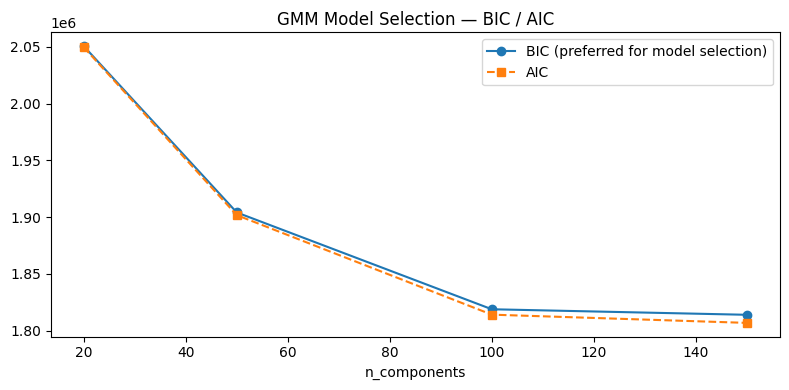

In [57]:
n_comp_range = [20, 50, 100, 150]
bic_list, aic_list = [], []

for nc in n_comp_range:
    print(f"GMM n={nc} ...", end=" ", flush=True)
    gmm = GaussianMixture(n_components=nc, covariance_type='diag',
                          random_state=42, n_init=1, max_iter=150)
    gmm.fit(X)
    bic_list.append(gmm.bic(X))
    aic_list.append(gmm.aic(X))
    print(f"BIC={bic_list[-1]:.0f}  AIC={aic_list[-1]:.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_comp_range, bic_list, 'o-',  label='BIC (preferred for model selection)')
ax.plot(n_comp_range, aic_list, 's--', label='AIC')
ax.set(title='GMM Model Selection — BIC / AIC', xlabel='n_components')
ax.legend()
plt.tight_layout()
plt.show()

Best n_components by BIC: 150


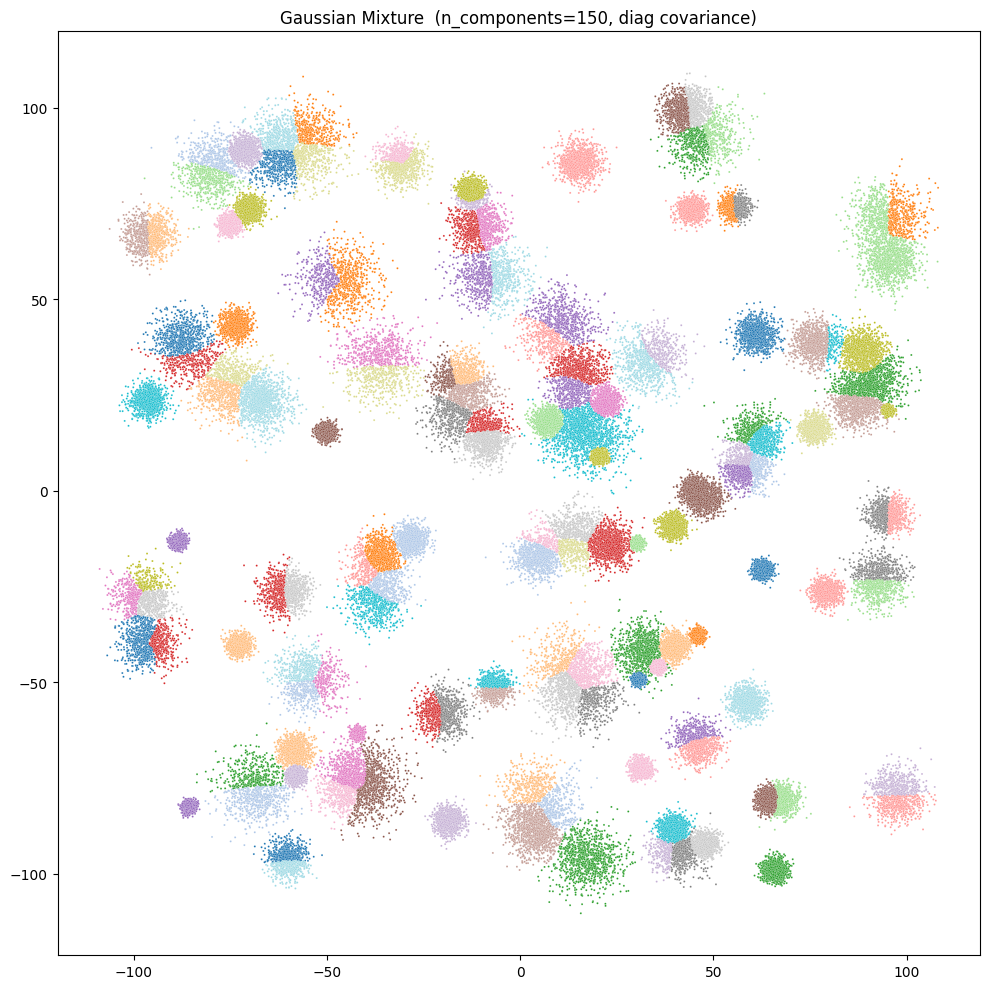

In [58]:
best_nc = n_comp_range[int(np.argmin(bic_list))]
print(f"Best n_components by BIC: {best_nc}")

gmm_best = GaussianMixture(n_components=best_nc, covariance_type='diag',
                              random_state=42, n_init=1, max_iter=300)
labels_gmm = gmm_best.fit_predict(X)

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_gmm.astype(str),
                s=2, legend=False, palette='tab20', ax=ax)
ax.set_title(f'Gaussian Mixture  (n_components={best_nc}, diag covariance)')
plt.tight_layout()
plt.show()

## BIRCH

**BIRCH** (Balanced Iterative Reducing and Clustering using Hierarchies) was designed
specifically for **large datasets** (like our 100 K points).
It builds a compact **CF-tree** of micro-clusters in one pass, then optionally runs
a global clustering (here K-Means) on the leaf nodes.

It is typically the **fastest** algorithm on BIRCH-3 — ironically the dataset was
created to benchmark this algorithm.

BIRCH -> 100 clusters


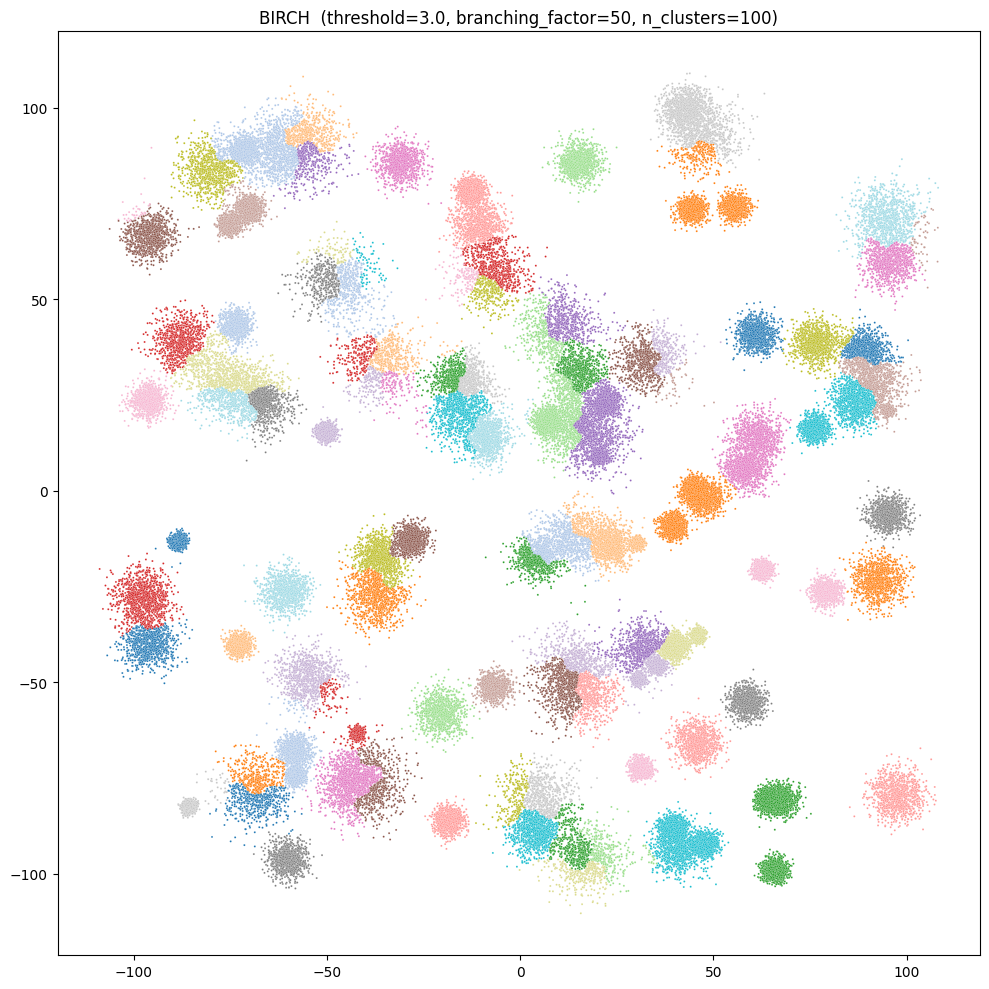

In [ ]:
birch = Birch(n_clusters=100, threshold=3.0, branching_factor=50)
labels_birch = birch.fit_predict(X)

n_cl_birch = len(np.unique(labels_birch))
print(f"BIRCH -> {n_cl_birch} clusters")

fig, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels_birch.astype(str),
                s=2, legend=False, palette='tab20', ax=ax)
ax.set_title('BIRCH  (threshold=3.0, branching_factor=50, n_clusters=100)')
plt.tight_layout()
plt.show()

## Metrics Comparison

### Silhouette · Davies-Bouldin · Pair Confusion

| Metric | Range | Best | Notes |
|--------|-------|------|-------|
| **Silhouette Score** | −1 → 1 | → 1 | Compactness vs. separation; computed on 10 K subsample |
| **Davies-Bouldin** | ≥ 0 | → 0 | Average pairwise cluster similarity |
| **Pair Confusion Matrix** | — | — | Agreement of pairwise co-cluster decisions vs. reference |

For density-based methods, noise points (label = −1) are **excluded** before scoring.
OPTICS is excluded from Pair Confusion — it was fitted on a different subsample.

In [ ]:
def safe_silhouette(Xm, lbl, n=10_000, seed=0):
    mask = lbl != -1
    Xf, lf = Xm[mask], lbl[mask]
    if len(set(lf)) < 2:
        return float('nan')
    idx = np.random.default_rng(seed).choice(len(Xf), min(n, len(Xf)), replace=False)
    try:
        return round(float(silhouette_score(Xf[idx], lf[idx])), 4)
    except Exception:
        return float('nan')

def safe_db(Xm, lbl):
    mask = lbl != -1
    if len(set(lbl[mask])) < 2:
        return float('nan')
    try:
        return round(float(davies_bouldin_score(Xm[mask], lbl[mask])), 4)
    except Exception:
        return float('nan')

# OPTICS subsample stored separately (X_op, labels_optics_sub)
label_sets = [
    (f'KMeans K={best_k}', X, labels_kmeans),
    ('DBSCAN', X, labels_dbscan),
    ('HDBSCAN', X, labels_hdbscan),
    (f'OPTICS (20K sub)', X_op, labels_optics_sub),
    (f'GMM n={best_nc}', X, labels_gmm),
    ('BIRCH', X, labels_birch),
] 

rows = []
for name, Xm, lbl in label_sets:
    n_cl  = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise = int((lbl == -1).sum())
    rows.append({
        'Method': name,
        '# Clusters': n_cl,
        'Noise pts': noise,
        'Silhouette ↑': safe_silhouette(Xm, lbl),
        'Davies-Bouldin ↓': safe_db(Xm, lbl),
    })

metrics_df = pd.DataFrame(rows).set_index('Method')
metrics_df

,# Clusters,Noise pts,Silhouette ↑,Davies-Bouldin ↓
Method,,,,
KMeans K=50,50,0,0.5660,0.5848
DBSCAN,16,15,0.1330,0.7835
HDBSCAN,72,11331,0.6442,0.4373
OPTICS (20K sub),16,8973,0.6785,0.4469
GMM n=150,150,0,0.4615,0.9288
BIRCH,100,0,0.5000,0.7877


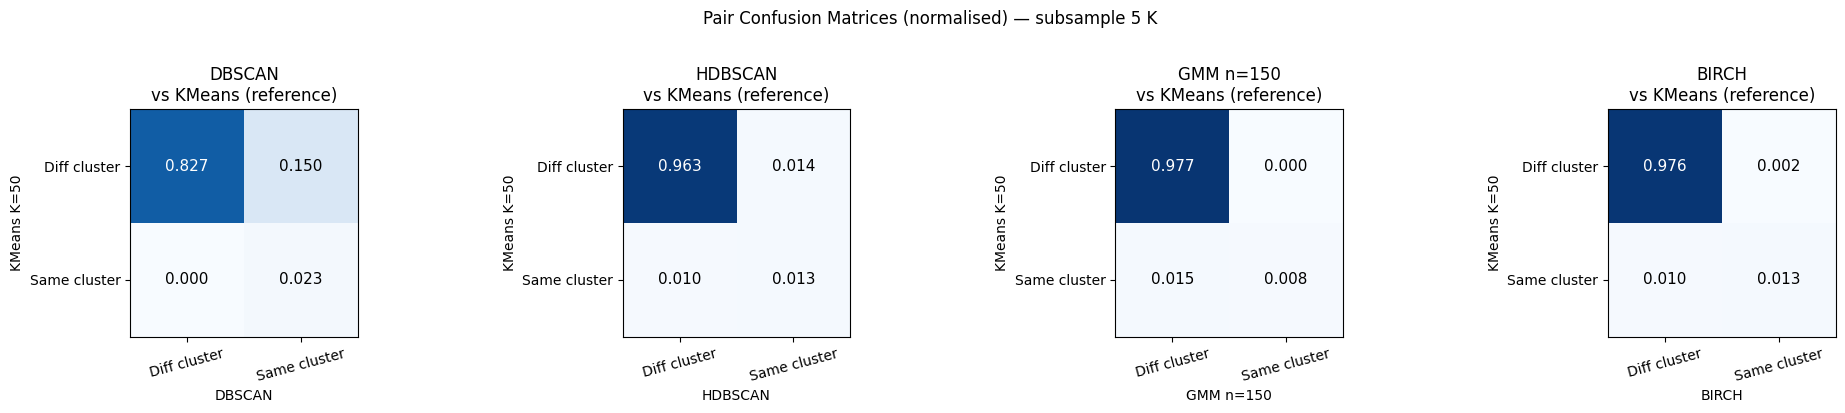

In [ ]:
# Pair Confusion Matrix
# All algorithms are compared against K-Means: "reference" labelling.

ref_lbl = labels_kmeans
compare  = {
    'DBSCAN': labels_dbscan,
    'HDBSCAN': labels_hdbscan,
    f'GMM n={best_nc}': labels_gmm,
    'BIRCH': labels_birch,
}

pcm_n = 5000
pcm_idx = rng.choice(len(X), pcm_n, replace=False)

tick_labels = ['Diff cluster', 'Same cluster']
fig, axes = plt.subplots(1, len(compare), figsize=(5 * len(compare), 4))

for ax, (title, lbl) in zip(axes, compare.items()):
    pcm = pair_confusion_matrix(ref_lbl[pcm_idx], lbl[pcm_idx])
    pcm_norm = pcm.astype(float) / pcm.sum()
    ax.imshow(pcm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set(xticks=[0, 1], yticks=[0, 1],
           xticklabels=tick_labels, yticklabels=tick_labels,
           xlabel=title, ylabel=f'KMeans K={best_k}')
    ax.tick_params(axis='x', rotation=15)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{pcm_norm[i, j]:.3f}', ha='center', va='center',
                    fontsize=11,
                    color='white' if pcm_norm[i, j] > 0.55 else 'black')
    ax.set_title(f'{title}\nvs KMeans (reference)')

plt.suptitle('Pair Confusion Matrices (normalised) — subsample 5 K', y=1.02)
plt.tight_layout()
plt.show()